# modeling4.ipynb — LOOCV with Zero Imputation

> Compare against `modeling3.ipynb` (median imputation) to see whether filling missing peptide intensities with **zero** instead of the training-fold median changes classification accuracy.

**Why zero imputation?**  
In mass spectrometry, a missing (zero) intensity usually means the peptide was below the instrument's detection limit rather than truly absent. Replacing missing values with zero preserves that "not detected" signal, which can be informative for separating Severe vs Non-severe patients. Median imputation, by contrast, replaces missing values with a typical detected intensity — blurring the distinction between detected and undetected peptides.

**Vectorised feature selection**  
Instead of looping over each of the ~101 k peptides one at a time, all t-tests and Mann-Whitney U tests for a fold are run in a single vectorised call using `scipy`'s `axis=0` parameter. This is equivalent to the per-peptide loop but 50-100x faster — no GPU needed.

## Step 1 — Load the full cleaned dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.model_selection import LeaveOneOut
from sklearn.base import clone

df        = pd.read_csv("variants_filtered.tsv", sep="\t", index_col=0)
condition = df["Condition"]
X         = df.drop(columns=["Condition"])
y         = condition.map({"Non-severe-COVID-19": 0, "Severe-COVID-19": 1})

print(f"Full dataset : {X.shape[0]} patients × {X.shape[1]} peptides")
print(f"\nCondition counts:")
print(condition.value_counts())
print(f"\nMissing value rate: {X.isna().mean().mean():.1%} of all entries are NaN")
print(f"These will be filled with 0 (not-detected signal) instead of training-fold median.")

Full dataset : 43 patients × 101461 peptides

Condition counts:
Condition
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64

Missing value rate: 59.0% of all entries are NaN
These will be filled with 0 (not-detected signal) instead of training-fold median.


## Step 2 — Define model pipelines

Identical to `modeling3.ipynb` except the imputer uses `strategy="constant", fill_value=0` instead of `strategy="median"`.  
`clone()` is used inside the loop to create a fresh unfitted copy of each pipeline for every fold.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
N_FEATURES   = 200

model_templates = {
    "logistic_regression_l2": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l2", C=1.0, class_weight="balanced",
            max_iter=5000, random_state=RANDOM_STATE,
        )),
    ]),
    "logistic_regression_l1": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l1", C=0.2, solver="liblinear", class_weight="balanced",
            max_iter=5000, random_state=RANDOM_STATE,
        )),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("model",   RandomForestClassifier(
            n_estimators=500, max_depth=3, min_samples_leaf=2,
            class_weight="balanced", random_state=RANDOM_STATE,
        )),
    ]),
}

print("Model templates (zero imputation):")
for name, pipe in model_templates.items():
    imp = pipe.named_steps["imputer"]
    print(f"  {name}: imputer={imp.strategy}, fill_value={imp.fill_value}")

Model templates (zero imputation):
  logistic_regression_l2: imputer=constant, fill_value=0
  logistic_regression_l1: imputer=constant, fill_value=0
  random_forest: imputer=constant, fill_value=0


## Step 3 — LOOCV loop (vectorised feature selection)

For each of the 43 folds:
1. Hold out 1 patient
2. Run **vectorised** t-test and Mann-Whitney U on all peptides at once using `scipy`'s `axis=0` parameter (replaces the per-peptide Python loop from `modeling3.ipynb`)
3. Select top 200 peptides from training data only
4. Apply those same 200 columns to the held-out patient
5. Fit each pipeline and predict

**Why vectorised is faster:** instead of calling `ttest_ind` 101,461 times (once per peptide), we pass the full matrices to scipy which processes all columns in one optimised C-level call. Same result, ~50-100x fewer Python function calls.

In [3]:
loo = LeaveOneOut()

loocv_results = {
    name: {"y_true": [], "y_pred": [], "y_score": []}
    for name in model_templates
}

for fold, (train_idx, test_idx) in enumerate(loo.split(X)):
    X_train_fold = X.iloc[train_idx]   # 42 patients × 101,461 peptides
    X_test_fold  = X.iloc[test_idx]    # 1 patient  × 101,461 peptides
    y_train_fold = y.iloc[train_idx]
    y_test_fold  = y.iloc[test_idx]

    # ── Vectorised feature selection on training fold only ────────
    condition_fold = y_train_fold.map({0: "Non-severe-COVID-19", 1: "Severe-COVID-19"})

    X_sv_arr  = X_train_fold.loc[condition_fold == "Severe-COVID-19"].values.astype(float)
    X_nsv_arr = X_train_fold.loc[condition_fold == "Non-severe-COVID-19"].values.astype(float)

    # Count non-NaN observations per peptide in each group
    n_sv  = np.sum(~np.isnan(X_sv_arr),  axis=0)
    n_nsv = np.sum(~np.isnan(X_nsv_arr), axis=0)
    valid = (n_sv >= 3) & (n_nsv >= 3)   # need ≥3 observations per group

    # Run all t-tests and Mann-Whitney U tests in one vectorised call
    _, t_pvals  = ttest_ind(X_sv_arr, X_nsv_arr, axis=0, equal_var=False, nan_policy="omit")
    _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")

    # Invalidate peptides with too few observations in either group
    t_pvals[~valid]  = np.nan
    mw_pvals[~valid] = np.nan

    stats_fold = (
        pd.DataFrame({
            "Peptide"            : X_train_fold.columns,
            "mannwhitney_pvalue" : mw_pvals,
            "t_pvalue"           : t_pvals,
        })
        .sort_values(["mannwhitney_pvalue", "t_pvalue"], na_position="last")
        .reset_index(drop=True)
    )

    selected = (
        stats_fold
        .dropna(subset=["mannwhitney_pvalue"])
        .head(N_FEATURES)["Peptide"]
        .tolist()
    )

    X_tr = X_train_fold[selected]
    X_te = X_test_fold[selected]   # same 200 columns, no re-selection

    # ── Train each model and predict the held-out patient ─────────
    for name, template in model_templates.items():
        pipe = clone(template)     # fresh unfitted copy for this fold
        pipe.fit(X_tr, y_train_fold)
        pred  = pipe.predict(X_te)[0]
        score = pipe.predict_proba(X_te)[0, 1]
        loocv_results[name]["y_true"].append(y_test_fold.iloc[0])
        loocv_results[name]["y_pred"].append(pred)
        loocv_results[name]["y_score"].append(score)

    if (fold + 1) % 10 == 0 or (fold + 1) == len(y):
        print(f"Fold {fold+1:2d}/{len(y)} complete")

print("\nLOOCV complete.")

c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_20536\1737586274.py:27: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation f

Fold 10/43 complete


c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_20536\1737586274.py:27: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation f

Fold 20/43 complete


c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_20536\1737586274.py:27: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation f

Fold 30/43 complete


c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_20536\1737586274.py:27: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation f

Fold 40/43 complete


c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_20536\1737586274.py:27: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation f

Fold 43/43 complete

LOOCV complete.


## Step 4 — Compare model performance across all 43 folds

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

comparison_rows = []
for name, res in loocv_results.items():
    y_true  = res["y_true"]
    y_pred  = res["y_pred"]
    y_score = res["y_score"]
    comparison_rows.append({
        "model"            : name,
        "accuracy"         : accuracy_score(y_true, y_pred),
        "precision_severe" : precision_score(y_true, y_pred, zero_division=0),
        "recall_severe"    : recall_score(y_true, y_pred, zero_division=0),
        "f1_severe"        : f1_score(y_true, y_pred, zero_division=0),
        "roc_auc"          : roc_auc_score(y_true, y_score),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["f1_severe", "roc_auc", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("LOOCV results — zero imputation (aggregated across all 43 folds):")
print(model_comparison.to_string(index=False))

LOOCV results — zero imputation (aggregated across all 43 folds):
                 model  accuracy  precision_severe  recall_severe  f1_severe  roc_auc
logistic_regression_l2  0.906977          0.888889       0.888889   0.888889 0.966667
logistic_regression_l1  0.813953          0.727273       0.888889   0.800000 0.926667
         random_forest  0.790698          0.846154       0.611111   0.709677 0.924444


## Step 5 — Select best model and inspect per-patient predictions

In [5]:
from sklearn.metrics import classification_report

best_model_name = model_comparison.loc[0, "model"]
best_res        = loocv_results[best_model_name]

predictions_df = pd.DataFrame({
    "patient"            : X.index,
    "true_condition"     : pd.Series(best_res["y_true"]).map({0: "Non-severe", 1: "Severe"}).values,
    "predicted_condition": pd.Series(best_res["y_pred"]).map({0: "Non-severe", 1: "Severe"}).values,
    "severe_probability" : best_res["y_score"],
    "correct"            : [t == p for t, p in zip(best_res["y_true"], best_res["y_pred"])],
})

print(f"Best model: {best_model_name}")
print(f"\nPer-patient LOOCV predictions:")
print(predictions_df.to_string(index=False))

print(f"\n── LOOCV Metrics ({best_model_name}) ──────────────────────")
print(f"Accuracy  : {accuracy_score(best_res['y_true'], best_res['y_pred']):.3f}")
print(f"Precision : {precision_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"Recall    : {recall_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"F1        : {f1_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"ROC-AUC   : {roc_auc_score(best_res['y_true'], best_res['y_score']):.3f}")
print()
print(classification_report(
    best_res["y_true"], best_res["y_pred"],
    target_names=["Non-severe", "Severe"], zero_division=0
))

Best model: logistic_regression_l2

Per-patient LOOCV predictions:
                             patient true_condition predicted_condition  severe_probability  correct
Non-severe-COVID-19.Patient-group-PT     Non-severe              Severe            0.797304    False
             Non-severe-COVID-19.XG1     Non-severe          Non-severe            0.017646     True
            Non-severe-COVID-19.XG10     Non-severe          Non-severe            0.304459     True
            Non-severe-COVID-19.XG11     Non-severe          Non-severe            0.006729     True
            Non-severe-COVID-19.XG13     Non-severe          Non-severe            0.003092     True
            Non-severe-COVID-19.XG14     Non-severe          Non-severe            0.021883     True
            Non-severe-COVID-19.XG15     Non-severe          Non-severe            0.001725     True
            Non-severe-COVID-19.XG16     Non-severe          Non-severe            0.000145     True
            Non-severe-C

## Step 6 — Confusion Matrix

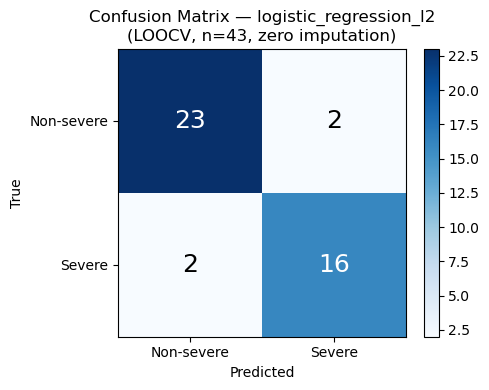

True Negatives  (Non-severe → Non-severe): 23
False Positives (Non-severe → Severe)    : 2
False Negatives (Severe → Non-severe)    : 2
True Positives  (Severe → Severe)        : 16


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm     = confusion_matrix(best_res["y_true"], best_res["y_pred"])
labels = ["Non-severe", "Severe"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {best_model_name}\n(LOOCV, n=43, zero imputation)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=18, color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Non-severe → Non-severe): {tn}")
print(f"False Positives (Non-severe → Severe)    : {fp}")
print(f"False Negatives (Severe → Non-severe)    : {fn}")
print(f"True Positives  (Severe → Severe)        : {tp}")

## Step 7 — Precision-Recall Curve

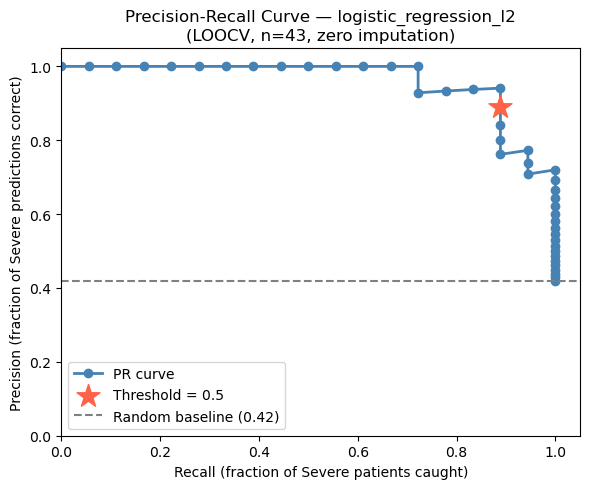

In [7]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(
    best_res["y_true"], best_res["y_score"]
)
default_idx = np.argmin(np.abs(thresholds - 0.5))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_vals, precision_vals, marker="o", color="steelblue", linewidth=2, label="PR curve")
ax.scatter(recall_vals[default_idx], precision_vals[default_idx],
           marker="*", s=300, color="tomato", zorder=5, label="Threshold = 0.5")
ax.axhline(np.mean(best_res["y_true"]), linestyle="--", color="grey",
           label=f"Random baseline ({np.mean(best_res['y_true']):.2f})")
ax.set_xlabel("Recall (fraction of Severe patients caught)")
ax.set_ylabel("Precision (fraction of Severe predictions correct)")
ax.set_title(f"Precision-Recall Curve — {best_model_name}\n(LOOCV, n=43, zero imputation)")
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 — Compare zero vs median imputation (LOOCV)

Side-by-side comparison of this notebook (zero imputation) against `modeling3.ipynb` (median imputation), using the best model from each.

In [8]:
# Hardcoded modeling3.ipynb best-model (LR L2, median imputation) results from checkpoint6.md
median_results = {
    "accuracy"         : 0.906977,
    "precision_severe" : 0.888889,
    "recall_severe"    : 0.888889,
    "f1_severe"        : 0.888889,
    "roc_auc"          : 0.944444,
}

best_loocv = model_comparison.iloc[0]

comparison = pd.DataFrame({
    "LOOCV median imputation (modeling3.ipynb)" : median_results,
    "LOOCV zero imputation   (modeling4.ipynb)" : best_loocv[["accuracy","precision_severe","recall_severe","f1_severe","roc_auc"]].to_dict(),
}).T

print(f"Median imputation best model : logistic_regression_l2")
print(f"Zero   imputation best model : {best_model_name}")
print()
print(comparison.round(3).to_string())

Median imputation best model : logistic_regression_l2
Zero   imputation best model : logistic_regression_l2

                                           accuracy  precision_severe  recall_severe  f1_severe  roc_auc
LOOCV median imputation (modeling3.ipynb)     0.907             0.889          0.889      0.889    0.944
LOOCV zero imputation   (modeling4.ipynb)     0.907             0.889          0.889      0.889    0.967


## Step 9 — Save results and retrain final model on all 43 patients

Performance was already estimated by LOOCV. Retraining on all 43 patients produces a final model for feature importance inspection.

In [9]:
import joblib

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

model_comparison.to_csv(MODEL_DIR / "modeling4_loocv_comparison.tsv",  sep="\t", index=False)
predictions_df.to_csv(  MODEL_DIR / "modeling4_loocv_predictions.tsv", sep="\t", index=False)

# Feature selection on all 43 patients for final model (inspection only)
X_sv_all  = X.loc[y == 1].values.astype(float)
X_nsv_all = X.loc[y == 0].values.astype(float)

n_sv_all  = np.sum(~np.isnan(X_sv_all),  axis=0)
n_nsv_all = np.sum(~np.isnan(X_nsv_all), axis=0)
valid_all  = (n_sv_all >= 3) & (n_nsv_all >= 3)

_, t_pvals_all  = ttest_ind(X_sv_all, X_nsv_all, axis=0, equal_var=False, nan_policy="omit")
_, mw_pvals_all = mannwhitneyu(X_sv_all, X_nsv_all, axis=0, alternative="two-sided", nan_policy="omit")

t_pvals_all[~valid_all]  = np.nan
mw_pvals_all[~valid_all] = np.nan

stats_all_df = (
    pd.DataFrame({
        "Peptide"            : X.columns,
        "mannwhitney_pvalue" : mw_pvals_all,
        "t_pvalue"           : t_pvals_all,
    })
    .sort_values(["mannwhitney_pvalue", "t_pvalue"], na_position="last")
    .reset_index(drop=True)
)

final_peptides = stats_all_df.dropna(subset=["mannwhitney_pvalue"]).head(N_FEATURES)["Peptide"].tolist()

final_model = clone(model_templates[best_model_name])
final_model.fit(X[final_peptides], y)

joblib.dump(final_model, MODEL_DIR / "modeling4_final_model.joblib")
(MODEL_DIR / "modeling4_best_model_name.txt").write_text(best_model_name + "\n")
pd.Series(final_peptides).to_csv(MODEL_DIR / "modeling4_selected_peptides.txt", index=False, header=False)

print("Saved:")
print("  modeling4_loocv_comparison.tsv   — LOOCV metrics for all 3 models (zero imputation)")
print("  modeling4_loocv_predictions.tsv  — per-patient predictions from best model")
print("  modeling4_final_model.joblib     — best model retrained on all 43 patients")
print("  modeling4_best_model_name.txt    — best model name")
print("  modeling4_selected_peptides.txt  — 200 peptides selected from full dataset")

c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_20536\4093226497.py:18: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals_all = mannwhitneyu(X_sv_all, X_nsv_all, axis=0, alternative="two-sided", nan_policy="omit")


Saved:
  modeling4_loocv_comparison.tsv   — LOOCV metrics for all 3 models (zero imputation)
  modeling4_loocv_predictions.tsv  — per-patient predictions from best model
  modeling4_final_model.joblib     — best model retrained on all 43 patients
  modeling4_best_model_name.txt    — best model name
  modeling4_selected_peptides.txt  — 200 peptides selected from full dataset
